In [1]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_root = r"E:/Studies/Self/CCTV-Threat-Detection/Data/Smart-City-CCTV-Violence-Detection-Dataset (SCVD)/SCVD_converted"
train_dir = os.path.join(dataset_root, "Train")
test_dir = os.path.join(dataset_root, "Test")

classes = ["Normal", "Violence", "Weaponized"]
print("Classes:", classes)

Classes: ['Normal', 'Violence', 'Weaponized']


In [ ]:
class VideoDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, frames_per_clip=32):
        self.samples = []
        self.transform = transform
        self.frames_per_clip = frames_per_clip
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            class_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(class_dir):
                if fname.endswith(".avi"):
                    self.samples.append((os.path.join(class_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        cap = cv2.VideoCapture(video_path)
        frames = []
        while len(frames) < self.frames_per_clip and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
        cap.release()

        # Pad if fewer frames
        while len(frames) < self.frames_per_clip:
            frames.append(torch.zeros_like(frames[0]))

        video_tensor = torch.stack(frames)  # shape: (T, C, H, W)
        # Rearrange to (C, T, H, W) for SlowFast input
        video_tensor = video_tensor.permute(1, 0, 2, 3)
        return video_tensor, label

In [4]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.45, 0.45, 0.45],
                         std=[0.225, 0.225, 0.225])
])

train_dataset = VideoDataset(train_dir, classes, transform, frames_per_clip=32)
test_dataset = VideoDataset(test_dir, classes, transform, frames_per_clip=32)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 399
Test samples: 82


In [5]:
model = torch.hub.load('facebookresearch/pytorchvideo', 'slowfast_r50', pretrained=True)

# Replace classifier head for SCVD (3 classes)
model.blocks[-1].proj = nn.Linear(model.blocks[-1].proj.in_features, len(classes))

# Freeze backbone, train only classifier head
for param in model.parameters():
    param.requires_grad = False
for param in model.blocks[-1].proj.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

Using cache found in C:\Users\risha/.cache\torch\hub\facebookresearch_pytorchvideo_main


Downloading: "https://dl.fbaipublicfiles.com/pytorchvideo/model_zoo/kinetics/SLOWFAST_8x8_R50.pyth" to C:\Users\risha/.cache\torch\hub\checkpoints\SLOWFAST_8x8_R50.pyth


100%|██████████| 264M/264M [00:23<00:00, 12.0MB/s] 


cuda


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.blocks[-1].proj.parameters(), lr=1e-4)

In [ ]:
def pack_pathway_output(frames, device):
    """
    Prepare inputs for SlowFast model.
    frames: tensor of shape (C, T, H, W)
    Returns: [slow_pathway, fast_pathway]
    """
    fast_pathway = frames
    index = torch.linspace(0, frames.shape[1]-1, frames.shape[1]//4).long().to(device)
    slow_pathway = torch.index_select(frames, 1, index)
    return [slow_pathway, fast_pathway]

In [12]:
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for videos, labels in train_loader:
        videos, labels = videos.to(device), labels.to(device)

        inputs = [pack_pathway_output(videos[i], device) for i in range(videos.shape[0])]
        slow = torch.stack([inp[0] for inp in inputs]).to(device)
        fast = torch.stack([inp[1] for inp in inputs]).to(device)

        outputs = model([slow, fast])

        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/20, Loss: 1.0514
Epoch 2/20, Loss: 1.0232
Epoch 3/20, Loss: 0.9822
Epoch 4/20, Loss: 0.9388
Epoch 5/20, Loss: 0.9372
Epoch 6/20, Loss: 0.9013
Epoch 7/20, Loss: 0.8918
Epoch 8/20, Loss: 0.8821
Epoch 9/20, Loss: 0.8492
Epoch 10/20, Loss: 0.8394
Epoch 11/20, Loss: 0.8171
Epoch 12/20, Loss: 0.8160
Epoch 13/20, Loss: 0.7772
Epoch 14/20, Loss: 0.7974
Epoch 15/20, Loss: 0.7917
Epoch 16/20, Loss: 0.7762
Epoch 17/20, Loss: 0.7707
Epoch 18/20, Loss: 0.7519
Epoch 19/20, Loss: 0.7421
Epoch 20/20, Loss: 0.7110


In [13]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for videos, labels in test_loader:
        videos, labels = videos.to(device), labels.to(device)

        inputs = [pack_pathway_output(videos[i], device) for i in range(videos.shape[0])]
        slow = torch.stack([inp[0] for inp in inputs]).to(device)
        fast = torch.stack([inp[1] for inp in inputs]).to(device)

        outputs = model([slow, fast])
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

              precision    recall  f1-score   support

      Normal       0.76      0.96      0.85        46
    Violence       0.50      0.17      0.25        12
  Weaponized       0.45      0.38      0.41        24

    accuracy                           0.67        82
   macro avg       0.57      0.50      0.50        82
weighted avg       0.63      0.67      0.63        82



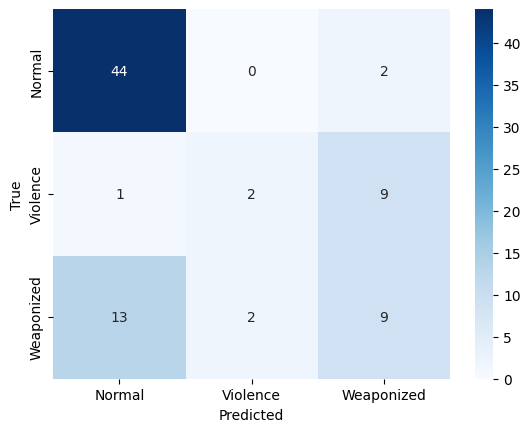

In [14]:
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()